激活函数的数量非常庞大，从经典的饱和函数到现代大模型的门控结构，可以归纳为以下几大类。

这里为你列出目前神经网络领域几乎所有已知且有影响力的激活函数：

1. 经典饱和类 (Classic Saturation)  
   
   Sigmoid (Logistic Function): 将输入压缩至 (0, 1)，常用于二分类，但易产生梯度消失。  

   Tanh (Hyperbolic Tangent Function): 将输入压缩至 (-1, 1)，零中心化特性使其收敛速度快于 Sigmoid。  

   Hard Sigmoid (Hard Sigmoid Function): Sigmoid 的分段线性近似，通过舍弃平滑性换取硬件计算速度。  

   Hard Tanh (Hard Hyperbolic Tangent Function): Tanh 的线性分段近似，常见于数值范围受限的早期架构。

2. ReLU 家族 (The ReLU Family) 
    
   ReLU (Rectified Linear Unit): $f(x)=\max(0, x)$。计算极快，解决了正向梯度饱和问题，是深层网络的标配。  
   
   Leaky ReLU (Leaky Rectified Linear Unit): 在 $x<0$ 时保留微小斜率，防止神经元在训练中“永久死亡”。  
   
   PReLU (Parametric Rectified Linear Unit): 负半轴斜率可学习，允许模型根据数据分布自动调整激活形状。  
   
   RReLU (Randomized Leaky Rectified Linear Unit): 训练时随机采样负斜率，增加噪声以起到正则化和抗过拟合作用。  
   
   ReLU6 (Rectified Linear Unit 6): 将输出上限限制在 6，提高模型在低比特量化（如 Int8）环境下的鲁棒性。  
   
   CReLU (Concatenated Rectified Linear Unit): 同时拼接正负激活特征，利用特征的“成对”属性增强表达能力。  
   
3. 指数与平滑类 (Smooth & Exponential)  
   
   ELU (Exponential Linear Unit): 负半轴采用指数过渡，均值更接近零，对噪声更鲁棒。  
   
   SELU (Scaled Exponential Linear Unit): 配合特定缩放因子，使网络具备“自归一化”特性。  
   
   CELU (Continuously Differentiable Exponential Linear Unit): ELU 的参数化修改，保证了全定义域内的一阶连续可微性。  
   
   GELU (Gaussian Error Linear Unit): 结合了 Dropout 的随机性思想，Transformer 架构的默认标准。  
   
   Softplus (Softplus Function): ReLU 的全平滑近似，数学性质优良，常用于需要连续梯度的任务。  
   
   Mish (Mish Function): 自正则化的非单调函数，曲线极其平滑，在 YOLO 系列等模型中表现出色。  
   
   Swish / SiLU (Sigmoid Linear Unit): $x \cdot \text{sigmoid}(x)$，由强化学习搜索出的最优形状，是大模型 Llama 的核心。  
   
4. 门控线性单元类 (GLU Family / LLM 统治级)  
   
   GLU (Gated Linear Unit): 通过一个分量的激活值作为“门”来控制另一个分量的信息流。  
   
   SwiGLU (Swish-Gated Linear Unit): GLU 结构与 Swish 的结合，目前 LLM 前馈网络（FFN）的最佳实践。  
   
   GeGLU (Gaussian Error Gated Linear Unit): 使用 GELU 作为门控信号的 GLU 变体，常见于 Google PaLM 等。  
   
   ReGLU (Rectified Linear Gated Linear Unit): 采用最原始的 ReLU 作为门控信号，平衡了性能与计算效率。
   
5. 移动端与轻量化类 (Hardware Optimized)  
   
   Hard-Swish (Hard Swish Function): 针对手机 CPU 指令集优化的 Swish，用 ReLU6 模拟 Sigmoid，速度极快。  
   
   Hard-Sigmoid (Hard Sigmoid Function): 专门用于端侧推理的 Sigmoid 近似，避免了昂贵的指数运算。

6. 多输入与自适应类 (Adaptive & Multi-input)  
   
   Maxout (Maxout Unit): 输出多个线性函数的最大值，本质上是在学习一个最适合数据的分段函数。  
   
   Softmax (Softmax Function): 将向量归一化为总和为 1 的概率分布，多分类输出层的唯一选择。  
   
   LogSoftmax (Log-Softmax Function): Softmax 的对数版本，提升了损失函数计算的数值稳定性。  
   
   Sparsemax (Sparsemax Function): 欧几里得投影下的概率映射，能输出真正的 0 权重，提升注意力解释性。
   
7. 其他类 (Exotic & Mathematical)  
   
   Softsign (Softsign Function): Tanh 的多项式近似，饱和速度比 Tanh 慢，能提供更持久的梯度。  
   
   Bent-Identity (Bent-Identity Function): 给线性函数加了一点“弯曲”，保留了无限延伸特性同时打破了线性。  
   
   Sinc (Cardinal Sine Function): $\sin(x)/x$，具有频域滤波特性，常用于语音及信号处理。  
   
   Gaussian (Gaussian Function): 局部响应激活，仅对原点附近的输入敏感，常见于 RBF 网络。  
   
   SQNL (Square Nonlinearity Function): 完全使用平方项模拟 S 型曲线，专为极简硬件加速器设计。

PyTorch 命名的小规律

作为层使用 (nn.Module)：
通常是全大写或者大驼峰，例如：

nn.ReLU()

nn.LeakyReLU()

nn.Hardsigmoid()

nn.Hardtanh()

nn.Softmax()

作为函数使用 (nn.functional)：
通常是全小写，并用下划线连接，例如：

F.relu()

F.leaky_relu()

F.hardsigmoid()

F.hardtanh()

F.softmax()

### 按照上面给出的顺序，下面依次进行说明，以前已经知道的就不再重复说明了
其中，ReLu、Sigmoid、Tanh、softmax、Gelu、Swiglu是最常用到的

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l
import torch.nn as nn
import torch.nn.functional as F

def visualize_activation(x , activate):
    # 1. 前向传播
    y = activate(x)
    
    # 2. 反向传播计算梯度
    if x.grad is not None: x.grad.zero_() # 清除旧梯度
    y.backward(torch.ones_like(x), retain_graph=True)
    
    # 注意：我们将 x 传两次，y 和 x.grad 分别对应两条线
    d2l.plot([x.detach(), x.detach()], 
             [y.detach(), x.grad], 
             legend=['activation(x)', 'grad of activation'], # 添加图例区分
             xlabel='x', ylabel='f(x)', 
             figsize=(5, 2.5))

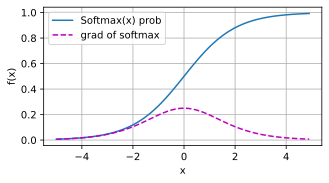

In [2]:
# 为了平滑显示图像，我们创建一个细致的向量
x = torch.arange(-5.0, 5.0, 0.1, requires_grad=True)

# 注意：Softmax 在一维向量上表现为所有元素的归一化
# 这里为了展示单个变量的变化趋势，我们将 x 视为一个序列，并计算其 Softmax
# 但通常 Softmax 是针对“一组”竞争对手的，
# 我们模拟两类分类情况：[x, 0]，看 x 变化时第一类的概率
input_tensor = torch.stack([x, torch.zeros_like(x)], dim=1) 
y_all = F.softmax(input_tensor, dim=1)
y = y_all[:, 0] # 我们只取第一项的概率：P = e^x / (e^x + e^0)

# 2. 反向传播计算梯度
y.backward(torch.ones_like(x), retain_graph=True)

# 3. 绘图
# 注意：Softmax 的形状在二分类情况下其实等同于 Sigmoid
d2l.plot([x.detach(), x.detach()], 
         [y.detach(), x.grad], 
         legend=['Softmax(x) prob', 'grad of softmax'], 
         xlabel='x', ylabel='f(x)', 
         figsize=(5, 2.5))

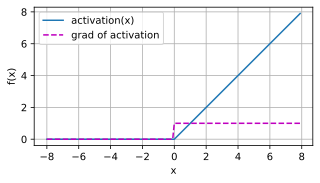

In [3]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
visualize_activation(x, torch.relu)

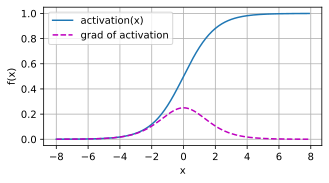

In [4]:
visualize_activation(x, torch.sigmoid)

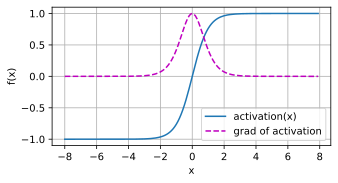

In [5]:
visualize_activation(x, torch.tanh)

Hardsigmoid 是一种为了工业部署而生的“效率先锋”。它用廉价的算术运算完美替代了昂贵的指数运算。  
1. 数学公式PyTorch 遵循 MobileNetV3 的标准定义，利用 ReLU6 来构建：  
$$f(x) = \frac{\text{ReLU6}(x + 3)}{6}$$
展开后的分段函数形式为：
$$f(x) = \begin{cases} 
0 & \text{if } x \le -3 \\
1 & \text{if } x \ge 3 \\
\frac{x}{6} + 0.5 & \text{otherwise}
\end{cases}$$
2. 核心精髓（特点）计算零成本：  
避开了 $e^x$ 复杂的泰勒级数展开。在底层硬件中，仅需一次加法、一次乘法（或移位）和两次截断（Clip）即可完成。  
量化亲和力：由于其分段线性的特性，在从 FP32 缩减到 INT8 精度时，它不会像原生的 Sigmoid 那样产生严重的数值扭曲，是量化感知训练（QAT）的理想选择。  
梯度固定：在激活区（-3 到 3）内，它的导数恒为 $1/6$。这避免了 Sigmoid 在接近 0 点时梯度变化剧烈的问题，使得局部学习更加稳定。  
边界硬化：相比于 Sigmoid 的无限趋近，它在 $\pm 3$ 处直接归零或归一，这能更彻底地关闭或开启“门控”。  
3. 适用场景轻量化视觉模型：  
它是 MobileNetV3 和 GhostNet 等模型的灵魂激活函数，专门用于手机端、嵌入式 NPU。  
注意力机制简化：在一些轻量级的注意力模块（如 SE-Block）中，用它替代 Sigmoid 来生成通道权重。  
端侧推理优化：当你需要将 PyTorch 模型通过 ONNX 导出到 TensorRT、NCNN 或 TFLite 部署时，使用 nn.Hardsigmoid 能获得显著的推理加速。

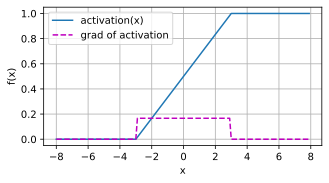

In [6]:
visualize_activation(x, F.hardsigmoid)

Hardtanh 是经典 Tanh (双曲正切) 函数的分段线性近似。就像 Hardsigmoid 之于 Sigmoid，Hardtanh 存在的意义是为了在保持 Tanh 核心特性的同时，抹除掉指数运算带来的沉重算力负担。  
1. 数学公式  
    在 PyTorch 中，Hardtanh 的标准定义非常直观，它本质上是一个带边界的截断线性函数：
    $$f(x) = \text{Hardtanh}(x) = \begin{cases}1 & \text{if } x > 1 \\ -1 & \text{if } x < -1 \\x & \text{otherwise}\end{cases}$$
    PyTorch 的 nn.Hardtanh 允许你自定义边界，默认值为 min_val=-1, max_val=1。  
2. 核心精髓（特点）  
    零中心化 (Zero-centered)：继承了 Tanh 的优良血统，输出均值接近 0。这有助于保持各层神经元输出的稳定性，加快模型收敛。  
    计算极其廉价：在代码底层，它仅仅是两次 clamp（钳制）操作。没有浮点数幂运算，对 CPU 和低端微控制器（MCU）极其友好。  
    梯度恒定：在激活区间（通常是 -1 到 1）内，它的导数恒为 1。  
        对比 Tanh：Tanh 的导数在 0 点最大，向两边递减。  
        优势：在激活区内完全不存在梯度消失问题，反向传播非常直接。  
    线性饱和：与 Tanh 无限趋近 $\pm 1$ 不同，Hardtanh 在达到边界后梯度立即变为 0。这种“硬饱和”有助于在某些任务中实现更彻底的特征抑制。  
3. 适用场景  
    生成对抗网络 (GANs)：在一些判别器或生成器的输出层，当需要将值限制在 $[-1, 1]$ 之间且追求推理速度时，Hardtanh 是首选。  
    模型量化与压缩：在二值化神经网络（Binary Neural Networks）或低比特量化网络中，Hardtanh 常被用来代替 Tanh，因为它更符合线性量化的逻辑。  
    语音处理：在一些实时的音频处理模型中，用于限制波形振幅，防止数值溢出，同时保持极低的计算延迟。  
    替代 ReLU：如果你发现模型使用 ReLU 时梯度更新不稳定，或者需要负值激活来平衡均值，可以将 Hardtanh 作为一个更温和、有界的替代品。

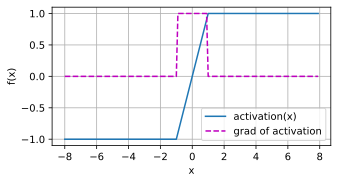

In [7]:
# 默认范围 [-1, 1]
activate = nn.Hardtanh(min_val=-1.0, max_val=1.0)
visualize_activation(x, activate)

Leaky ReLU（有漏值的 ReLU）是针对经典 ReLU 的致命缺陷——“神经元坏死”（Dead ReLU）而设计的改良方案。它在保留 ReLU 极速特性的同时，给负区间开了一扇“小门”。  
1. 数学公式  
    Leaky ReLU 在 $x < 0$ 时不再直接归零，而是乘以一个微小的斜率 $\alpha$：  
    $$f(x) = \max(\alpha x, x) = \begin{cases}x, & \text{if } x \ge 0 \\alpha x, & \text{if } x < 0\end{cases}$$
    在 PyTorch 的默认实现 nn.LeakyRelu 中，$\alpha$ (negative_slope) 默认为 0.01。  
2. 核心精髓（特点）  
    拯救“死掉”的神经元：  
        ReLU 的痛点：如果输入始终为负，梯度永远为 0，该神经元就会像死细胞一样不再更新。  
        Leaky 的解法：由于负区间存在微小梯度 $\alpha$，即便输入进入负值区，神经元依然能通过反向传播慢慢“醒过来”。  
    计算性能几乎零损耗：虽然多了一个乘法运算，但相比复杂的指数函数，它依然快如闪电，对硬件非常友好。  
    改善均值偏置：相比 ReLU 的输出均值总是大于 0，Leaky ReLU 允许负值输出，使每一层激活值的分布更接近于零中心，有助于网络训练的稳定性。  
    非饱和性：两端都没有上界，有效缓解了深层网络中的梯度消失问题。  
3. 适用场景  
   生成对抗网络 (GANs)：这是 Leaky ReLU 的“主战场”。判别器（Discriminator）几乎标配 Leaky ReLU，因为它能提供更丰富的梯度信息，防止梯度崩溃。  
   解决训练停滞：如果你发现你的模型在使用 ReLU 时，部分神经元的激活频率变低，或者 Loss 降不下去，换成 Leaky ReLU 通常会有奇效。  
   极深层网络：在不方便使用多种归一化（如 BatchNorm）的特殊架构中，它能比 ReLU 更好地保持梯度流动。

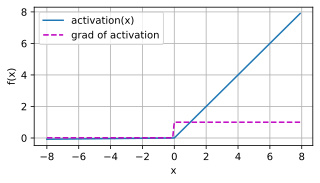

In [8]:
# negative_slope 即为公式中的 alpha，默认为 0.01
activate = nn.LeakyReLU(negative_slope=0.01)
visualize_activation(x, activate)

PReLU（参数化 ReLU）是 Leaky ReLU 的进阶进化版。它们最大的区别在于：Leaky ReLU 的负区间斜率 $\alpha$ 是你手动设定的死数字（如 0.01），而 PReLU 的 $\alpha$ 是一个可学习的参数。这意味着模型在训练过程中，会根据数据自动调整这个斜率，寻找最适合当前任务的激活形状。  
1. 数学公式
   $$f(x) = \max(0, x) + a \cdot \min(0, x) = \begin{cases}x, & \text{if } x \ge 0 \\ax, & \text{if } x < 0\end{cases}$$
   $a$ 是一个张量：它不是超参数，而是和权重 $W$、偏置 $b$ 一样，通过反向传播进行更新的参数。  
2. 核心精髓（特点）
   自适应激活：不同的通道（Channel）可以拥有不同的 $\alpha$。例如，某些通道可能需要保留较多的负反馈信息（$\alpha$ 较大），而某些通道则趋近于原始 ReLU（$\alpha \approx 0$）。  
   几乎零成本的灵活性：相比于增加网络深度或宽度，增加这几个 $\alpha$ 参数带来的计算开销微乎其微，但却显著提升了模型的拟合能力。  
   缓解过拟合：由于 $a$ 是学习出来的，它能更好地适应数据分布。研究表明，在大型数据集（如 ImageNet）上，PReLU 的表现通常优于 ReLU。  
   梯度流动性：由于负区间通常不会为 0，它彻底解决了神经元“坏死”的问题。  
3. 适用场景  
   深层卷积神经网络 (CNN)：在计算机视觉任务中，PReLU 是提升精度的常用手段。著名的 ResNet 变体或一些竞赛级模型常会尝试将其替换 ReLU。  
   小样本学习：当数据不足以支撑极其复杂的模型时，通过 PReLU 增加激活函数的灵活性有时能起到奇效。  
   性能敏感的高精度任务：如果你对推理速度要求很高，但又觉得 ReLU 精度不够，PReLU 是性价比最高的选择。

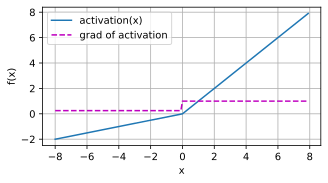

In [9]:
# num_parameters=1 表示所有通道共享一个 a
# 如果传入通道数（如 64），则每个通道拥有独立的 a
m = nn.PReLU(num_parameters=1, init=0.25)
visualize_activation(x, m)

RReLU（随机化 Leaky ReLU）是 Leaky ReLU 的一个非常独特的变体。在 PReLU 试图通过“学习”来寻找最优斜率时，RReLU 走了一条截然相反的道路：在训练过程中随机乱跳，在推理过程中固定不变。它最初是在 Kaggle 的图像分类竞赛中被提出来的，主要目的是为了通过引入噪声来抑制过拟合。  
1. 数学公式  
   在训练阶段，负区间的斜率 $a_{ji}$ 是从一个均匀分布 $U(l, u)$ 中随机采样出来的：  
   $$f(x_{ji}) = \begin{cases}x_{ji}, & \text{if } x_{ji} \ge 0 \\a_{ji} x_{ji}, & \text{if } x_{ji} < 0\end{cases}$$
   其中，$a_{ji} \sim U(l, u)$，$l < u$ 且 $l, u \in [0, 1)$。  
   在推理（测试）阶段，斜率固定为该分布的期望值：  $$a_{ji} = \frac{l + u}{2}$$
2. 核心精髓（特点）  
   天然的正则化器：由于训练时斜率是随机的，这相当于给网络注入了噪声，防止模型过于死记硬背训练集的负值分布，起到了类似 Dropout 的正则化作用。  
   训练与推理的不一致性：这是它最有趣的特点。训练时的“不确定性”增强了鲁棒性，而测试时的“确定性”保证了输出的稳定性。  
   解决神经元坏死：由于斜率 $a$ 通常取正值且不为 0，它依然保持了负区间的梯度流动。  
   计算开销平衡：虽然训练时需要生成随机数（稍微慢一点点），但推理时它就是一个普通的 Leaky ReLU，速度极快。  
3. 适用场景  
   容易过拟合的小数据集：当你的模型很大但数据量较小时，RReLU 能显著提升模型的泛化能力。  
   视觉竞赛项目：在需要压榨模型最后一点精度（SOTA）的场景下，RReLU 往往能比普通 ReLU 提升 0.5% - 1% 的准确率。  
   对噪声敏感的鲁棒性训练：如果希望模型对输入数据的微小扰动不那么敏感，这种带随机性的激活函数很有帮助。

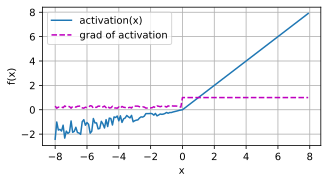

In [10]:
# lower 默认为 1/8, upper 默认为 1/3
m = nn.RReLU(lower=0.125, upper=0.333)
visualize_activation(x, m)

ReLU6 是对经典 ReLU 的一种简单而粗暴的改进。它在正向区间增加了一个“天花板”，将输出限制在 6 以内。这个看似随意的改动，实际上是为移动端低精度计算量身定制的。  
1. 数学公式  
   ReLU6 在 $x > 0$ 时不再无限增长，而是在达到 6 后水平截断：  
   $$f(x) = \min(\max(0, x), 6)$$
2. 核心精髓（特点）
   防止数值爆炸：  
    ReLU 的问题：正向区间没有上限，如果权重更新过大，激活值可能变得非常巨大。  
    ReLU6 的解法：通过强制截断，保证了输出值的动态范围是可控的。  
   低精度量化（Fixed-point）的最优选：在移动端（如手机、嵌入式芯片）中，为了提速，通常会将 32 位浮点数（FP32）压缩为 8 位定点数（INT8）。如果激活值范围是无限的，量化时的“步长”就会很大，导致精度损失严重。ReLU6 将范围锁定在 [0, 6]，使得 8 位整数可以非常精准地平分这块空间，从而显著减少量化误差。  
   硬件兼容性极佳：与 Hard-Sigmoid 类似，它不需要任何复杂的数学库支持，仅需两次逻辑判断（大于 0 和小于 6）即可。  
3. 适用场景  
   轻量化网络 (MobileNets)：它是 MobileNetV1 和 MobileNetV2 的核心激活函数。  
   嵌入式与端侧推理：当你打算将模型部署在树莓派、手机 NPU 或各种微控制器上时，ReLU6 是保持精度和速度平衡的最佳武器。  
   低比特训练：如果你正在研究 4-bit 或 8-bit 的极低精度神经网络，ReLU6 能提供比标准 ReLU 更稳定的表现。

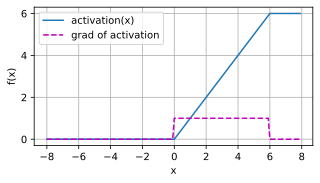

In [11]:
m = nn.ReLU6()
visualize_activation(x, m)

CReLU（级联 ReLU）是一个非常巧妙的设计，它源于视觉神经科学中的一个有趣发现：在深度卷积神经网络的早期层中，往往存在着大量成对的、极性相反的卷积核。简单来说，如果一个卷积核在学习捕捉“从黑到白”的边缘，通常会存在另一个卷积核在学习捕捉“从白到黑”的边缘。CReLU 利用这种“对称冗余”来直接让模型性能翻倍。
1. 数学公式  
   CReLU 将输入的每个值 $x$ 分别通过一个正向的 ReLU 和一个取负后的 ReLU，然后将结果拼接（Concatenate）在一起：  
   $$f(x) = [\max(0, x), \max(0, -x)]$$
   如果输入的张量维度是 $[B, C, H, W]$，经过 CReLU 激活后，输出维度会变成 $[B, 2C, H, W]$。  
2. 核心精髓（特点）  
   消除相位缺失（Phase Information Loss）：  
    ReLU 的痛点：ReLU 会强行抹去所有负值信息，导致模型在处理图像对比度反转时可能丢失特征。  
    CReLU 的解法：它同时保留了 $x$ 的正部和负部（负部取绝对值），使得每一层都拥有完整的响应信号。  
   自带“双倍特征”：在不增加参数量的情况下，通过拼接的方式让特征通道数翻倍。这在浅层网络（网络的前几层）中效果尤为显著。  
   计算与参数权衡：虽然通道数翻倍会增加后续层的计算量（FLOPs），但它减少了卷积核的学习难度，因为网络不需要再费力去学习重复的对称特征。    
3. 适用场景  
   轻量化目标检测 (SSD / YOLO 变体)：CReLU 最初是在 PVANet 中大放异彩的，常用于目标检测骨干网络（Backbone）的初始几层。  
   视觉特征提取的早期阶段：由于卷积网络前几层主要捕捉边缘、线条等低级特征，对称冗余最明显，使用 CReLU 效果最好。  
   小模型（Small Models）：当你想在极窄的网络里尽可能压榨出更多的特征信息时。

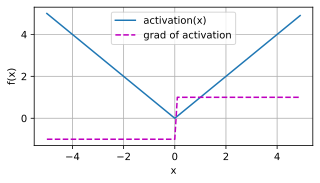

In [12]:
def crelu(x):
    # 将 x 和 -x 拼接在一起，然后整体做 ReLU
    return F.relu(torch.cat([x, -x], dim=1))

# 为了方便绘图，我们手动实现一个能输出单条曲线的逻辑
def crelu_visualize(x):
    # 标准 CReLU：[relu(x), relu(-x)]
    out = torch.cat([F.relu(x), F.relu(-x)], dim=0)
    # 为了在二维图上画出“效果”，我们将两个分量重新组合
    # 实际上 CReLU 效果等同于把负半轴翻转上来，形成一个 V 字型
    return F.relu(x) + F.relu(-x) 

x = torch.arange(-5.0, 5.0, 0.1, requires_grad=True)
visualize_activation(x, crelu_visualize)

ELU（指数线性单元）由 Clevert 等人在 2015 年提出，旨在解决 ReLU 的所有痛点：神经元坏死、均值偏移以及梯度不连续性。它被认为是 ReLU 家族中最“丝滑”的成员之一。
1. 数学公式  
   ELU 在正区间保持线性，在负区间则使用指数函数平滑地趋近于一个常数 $-\alpha$：  
   $$f(x) = \begin{cases}x, & \text{if } x > 0 \\ \alpha(e^x - 1), & \text{if } x \le 0\end{cases}$$
   在 PyTorch 的 nn.ELU 中，$\alpha$ 默认为 1.0。
2. 核心精髓（特点）  
   均值趋于零 (Zero-mean activations)：ReLU 的输出均值总是大于 0，这会导致后层神经元的输入产生偏置（Bias Shift）。ELU 在负区间有输出，使得激活值的平均值更接近于 0，从而像 Batch Normalization 一样起到加速收敛的作用。  
   平滑的饱和区：与 Leaky ReLU 那种笔直的负区间不同，ELU 的负区间是平滑弯曲的。这种软饱和特性使得模型对噪声（Outliers）更加鲁棒，不会因为负值方向的微小波动而产生剧烈的梯度跳变。  
   处处可导：当 $\alpha=1$ 时，ELU 在 $x=0$ 处的导数是连续的（左右导数均为 1）。这种连续性有助于优化算法（如 SGD）更稳定地寻找极小值。  
   计算开销：这是它唯一的“短板”。由于涉及 $e^x$ 指数运算，其计算量比 ReLU 大。但在现代显卡（GPU）面前，这点开销通常可以忽略不计。
3. 适用场景  
   深层全连接网络：在没有使用 Batch Normalization 的情况下，ELU 是保持层际平稳的首选。  
   自编码器 (Autoencoders)：由于其平滑的特性，在重构图像或信号时，生成的边界通常比 ReLU 更自然。  
   追求高泛化能力的视觉任务：在一些复杂的分类任务中，ELU 往往能比 ReLU 达到更高的准确率。

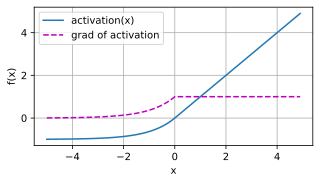

In [13]:
# alpha 默认为 1.0
m = nn.ELU(alpha=1.0)
visualize_activation(x, m)

SELU 是激活函数界的“数学怪兽”。它由 Klambauer 等人在 2017 年提出，其论文附录包含了长达 90 多页的数学证明。它的核心卖点是：自归一化（Self-Normalizing）。在传统的深度网络中，我们需要 Batch Normalization 来防止梯度消失或爆炸。而 SELU 的出现，使得网络即使不加任何 Normalization 层，也能在每一层保持激活值的均值为 0、方差为 1。  
1. 数学公式  
   SELU 实际上是 ELU 乘以一个缩放因子 $\lambda$：  
   $$f(x) = \lambda \begin{cases} x & \text{if } x > 0 \\ \alpha(e^x - 1) & \text{if } x \le 0 \end{cases}$$
   为了实现自归一化，这两个常数是固定死的（通过数学推导得出）：  
   $\alpha \approx 1.6732632423543772848170429916717$   
   $\lambda \approx 1.0507009873554804934193349852946$  
2. 核心精髓（特点）  
   内部自归一化 (Self-Normalizing Property)：这是 SELU 的绝活。它通过特定的形状，使得在长距离的传播中，神经元的分布会收敛到稳定的均值和方差。这解决了“梯度消失”和“梯度爆炸”问题，甚至可以让网络堆叠到几百层而不崩溃。  
   不连续梯度的消失：与 ReLU 的突变不同，SELU 在负半轴的平滑指数特性有助于更好的非线性映射。  
   训练速度快：因为它消除了对 Batch Normalization 层的依赖，每一层的计算开销更低，且没有 Batch Size 的限制。  
   前提条件严苛：必须配合特定的初始化方法：kaiming_normal 或 lecun_normal。必须用于全连接层（SNN, Self-Normalizing Neural Networks）。
3. 适用场景  
   极深的全连接网络 (MLP/FCN)：如果你在处理结构化数据（如金融预测、表格数据），且网络非常深，SELU 是目前的最优解。  
   无法使用 Batch Normalization 的场景：比如 Batch Size 非常小（甚至是 1），或者实时性要求极高、无法承受额外正则化层开销的任务。  
   自编码器与回归任务：其稳定的分布特性对数值预测非常有帮助。

对于BN或者LN归一化后的值 $\hat{x}$，最终输出为：  
$$y = \gamma \hat{x} + \beta$$
$\gamma,\beta$两个可学习参数，用于对归一化后的值做平移和缩放
<pre>
BN会在每个通道处得到一个均值和方差
张量阶数,   形状 (Input Shape),     对应 PyTorch 类,    均值/参数 γ,β 形状  
2阶,        "(N, C)",           nn.BatchNorm1d(C),      (C)  
3阶,        "(N, C, L)",        nn.BatchNorm1d(C),      (C)  
4阶,        "(N, C, H, W)",     nn.BatchNorm2d(C),      (C)  
5阶,        "(N, C, D, H, W)",  nn.BatchNorm3d(C),      (C)  

LN
场景,           输入形状,     normalized_shape (被压缩的维度),  均值/方差的形状 (剩下的维度),       "参数 γ,β 形状"     归一化计算范围
2阶 (MLP),      "(N,F)",        [F],                        "(N,1)",                            (F)            针对每个样本，计算其所有 Features 的均值/方差。
3阶 (NLP),      "(N,S,E)",      [E],                        "(N,S,1)",                          (E)            针对每个 Token，计算其 Embedding 向量内部的均值/方差。
4阶 (CV),       "(N,C,H,W)",    "[C,H,W]",                  "(N,1,1,1)",                        "(C,H,W)"      针对每张图片，计算全图所有像素和通道的均值/方差。
4阶 (Conv),     "(N,C,H,W)",    "[H,W]",                    "(N,C,1,1)",                        "(H,W)"        针对每个通道，计算该通道内整个平面的均值/方差。

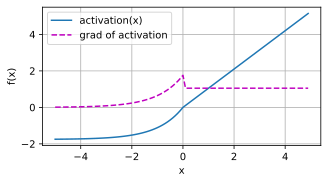

In [14]:
# 直接使用，无需参数
m = nn.SELU()

# 重要：通常需要配合 LeCun Normal 初始化
# nn.init.lecun_normal_(linear_layer.weight) # 实际工程中的推荐做法

visualize_activation(x, m)

CELU（连续可微指数线性单元）由 Barron 在 2017 年提出。从名字就能看出来，它是 ELU 的加强版。ELU 虽然在 $x=0$ 处平滑，但那是有条件的（必须 $\alpha=1$）。当 $\alpha \neq 1$ 时，ELU 在原点处的导数会出现阶跃。CELU 通过对公式进行微调，确保了无论 $\alpha$ 取什么值，函数在 $0$ 点处永远是连续可微的。
1. 数学公式
   CELU 的定义如下：  
   $$f(x) = \max(0, x) + \min(0, \alpha(e^{x/\alpha} - 1))$$
   也可以写成分段形式：  
   $$f(x) = \begin{cases}x, & \text{if } x \ge 0 \\ \alpha(e^{x/\alpha} - 1), & \text{if } x < 0\end{cases}$$
   在 PyTorch 的 nn.CELU 中，$\alpha$ 默认为 1.0。  
2. 核心精髓（特点）  
   完全连续可微：这是 CELU 的灵魂。对于 ELU，如果 $\alpha=2$，左导数是 2，右导数是 1；而 CELU 引入了 $x/\alpha$ 项，抵消了系数 $\alpha$ 对导数的影响，使得 $x=0$ 处的导数恒为 1。  
   尺度不变性 (Scale Invariance)：公式中的 $x/\alpha$ 使得激活函数的形状可以随着 $\alpha$ 同比例缩放。这意味着你可以通过调整 $\alpha$ 来改变负区间的“软度”，而不会破坏函数在原点的数学特性。  
   加速收敛：由于导数在原点处的平滑性，它在优化过程中比 ELU 更加稳定，能减少训练初期的震荡。  
   计算成本：由于涉及除法（$x/\alpha$）和指数运算，它的计算比 ReLU 慢。
3. 适用场景  
   对导数质量要求极高的任务：例如在某些二阶优化算法中，或者在需要计算高阶导数的物理信息神经网络（PINNs）中。  
   替代 ELU：如果你在使用 ELU 且发现 $\alpha$ 不等于 1 时模型训练不稳定，CELU 是直接的平替。  
   回归与高精度预测：其极高的平滑性有助于拟合更复杂的连续函数。

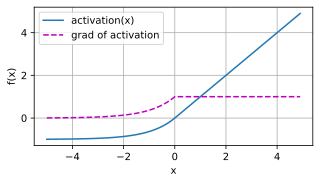

In [15]:
# alpha 默认为 1.0
# 注意：PyTorch 文档建议 alpha 必须非零
m = nn.CELU(alpha=1.0)
visualize_activation(x, m)

如果说 ReLU 是卷积神经网络（CNN）时代的王者，那么 GELU 就是大模型（Transformer）时代的霸主。它是 BERT、GPT 系列、Llama、ViT 等顶级架构的默认激活函数。GELU 由 Hendrycks 等人在 2016 年提出，它的核心思想是将正则化（Dropout）和激活函数融为一体。
1. 数学公式
   GELU 的本质是根据输入值 $x$ 在标准正态分布中的累积分布函数（CDF）来对 $x$ 进行加权：  
   $$f(x) = x \cdot P(X \le x) = x \cdot \Phi(x)$$
   其中 $\Phi(x)$ 是高斯分布的累积分布函数。由于精确计算比较复杂：  
   $$\Phi(x) = \int_{-\infty}^{x} \frac{1}{\sqrt{2\pi}} e^{-\frac{t^2}{2}} dt = \frac{1}{2} \left[ 1 + \text{erf}\left( \frac{x}{\sqrt{2}} \right) \right]$$
   其中，误差函数  
   $$\text{erf}(x) = \frac{2}{\sqrt{\pi}} \int_{0}^{x} e^{-t^2} dt$$
   通常使用以下高精度近似公式： 
   基于 Tanh 的近似：   
   $$f(x) \approx 0.5x \left( 1 + \tanh \left( \sqrt{\frac{2}{\pi}} (x + 0.044715x^3) \right) \right)$$
   基于 Sigmoid 的近似：
   $$f(x) \approx x \cdot \text{sigmoid}(1.702x)$$
2. 核心精髓（特点）  
   非确定性门控 (Probabilistic Gating)：ReLU 根据输入的正负符号硬性决定是否通过（0 或 1），而 GELU 根据输入值的大小，赋予一个被激活的“概率”。$x$ 越小，被清零的可能性越大；$x$ 越大，越可能被保留。  
   平滑性与曲率：GELU 在全定义域内都是光滑的（无限次可微）。与 ReLU 在 0 点的尖锐转折不同，GELU 有一个微小的“下凹陷”（在 $x \approx -0.75$ 处取得极小值约为 $-0.15$）。这种平滑性有助于捕捉更复杂的非线性模式。  
   负区间的活性：它允许微小的负值通过，这有助于在深层网络中保持梯度流动，且这种非单调性（先减后增）被证明在 Transformer 的注意力机制中非常有效。  
   现代硬件优化：虽然公式看起来可怕，但 PyTorch 和 CUDA 针对其近似公式做了极其深入的优化（Operator Fusion），在 GPU 上的执行速度几乎与 ReLU 相当。
3. 适用场景  
   Transformer 架构：只要你是在跑 NLP 任务（BERT/GPT/T5）或者视觉 Transformer（ViT），GELU 几乎是必选项。  
   极大规模模型训练：在大参数量下，GELU 的训练稳定性优于 ReLU。  
   需要高质量梯度的场景：由于其无限次可微的特性，在需要计算更高阶导数的任务中表现优异。

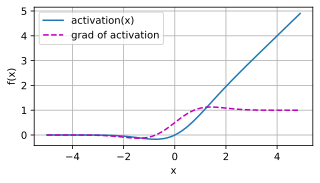

In [16]:
# approximate='none' 使用精确的高斯积分 (默认)
# approximate='tanh' 使用上述提到的 tanh 近似公式，速度更快
m = nn.GELU(approximate='none')
visualize_activation(x, m)

Softplus 可以被看作是 ReLU 的“丝滑平滑版”。它最早由 Dugas 等人在 2001 年提出，其最大的贡献在于提供了一个全定义域内连续可微且始终为正的函数形状。
1. 数学公式  
   Softplus 的定义是 $1$ 加上 $e^x$ 的自然对数：  
   $$f(x) = \ln(1 + e^x)$$
   当 $x$ 很大时，$1+e^x \approx e^x$，所以 $f(x) \approx x$；  
   当 $x$ 很小时，$1+e^x \approx 1$，所以 $f(x) \approx 0$。  
2. 核心精髓（特点）  
   平滑性（Smoothness）：ReLU 在 $x=0$ 处有一个硬转折（一阶导数不连续），而 Softplus 的导数是 Sigmoid 函数，这意味着它在任何点都是可导且光滑的。这种特性在需要高阶导数的优化算法中非常重要。  
   非负性约束：Softplus 的输出永远大于 $0$。在机器学习中，当我们预测的物理量必须为正数（如方差、步长、缩放系数）时，Softplus 是除了 exp 之外最常用的映射函数，且它比 exp 增长得更温和，不容易产生数值爆炸。  
   梯度流动：它的梯度（即 Sigmoid）在 $x=0$ 处不为零，即使输入为微小的负值，梯度依然能够传导，这比 ReLU 更有助于训练初期的参数调整。
3. 适用场景  
   预测正数值：在概率编程或变分自编码器（VAE）中，用于生成分布的方差（Variance）或标准差。  
   物理信息神经网络（PINNs）：因为物理公式通常涉及二阶导数，Softplus 的二阶连续性使其比 ReLU 更能适应偏微分方程的求解。  
   强化学习：在策略梯度算法中，用于将神经网络的输出转换为动作选择的概率（通常与 Softmax 配合，或作为分布参数）。

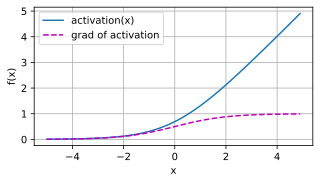

In [17]:
# 在 PyTorch 中，nn.Softplus 提供了一个 threshold 参数。当 $x \times \beta$ 超过这个阈值时，为了防止数值溢出，函数会自动切换成线性函数 $y=x$。
# beta 默认为 1, threshold 默认为 20
m = nn.Softplus(beta=1, threshold=20)
visualize_activation(x, m)

Mish 是由 Diganta Misra 在 2019 年提出的一个自门控（Self-Gated）激活函数。它并非由科技巨头实验室产出，而是由社区开发者通过大量的实验和数学分析筛选出来的。它被誉为 ReLU 的最强竞争对手之一，在 YOLOv4 等知名目标检测算法中大放异彩，证明了其在工业界实打实的 SOTA（State-of-the-art）能力。
1. 数学公式  
   Mish 的定义结合了 Tanh 和 Softplus，形成了一个极具美感的非线性曲线：  
   $$f(x) = x \cdot \tanh(\text{softplus}(x)) = x \cdot \tanh(\ln(1 + e^x))$$
2. 核心精髓（特点）  
   无上界但有下界：  
    无上界：避免了由于饱和导致的梯度消失（这一点和 ReLU 相同）。  
    有下界：产生了强烈的正则化效果，能抑制较强的负值。  
   非单调性（Non-monotonicity）：这是 Mish 的“秘诀”。在 $x$ 略小于 0 时，它会产生一个小的负向波动（极小值约为 $-0.308$）。这种特性被证明可以改善梯度流，并增强模型的表现力。  
   无限次连续可微（$C^\infty$ Smoothness）：与 ReLU 在 0 点的“剧烈碰撞”不同，Mish 极其平滑。这种平滑性使得信息在深度神经网络中传播得更加深远，且对于初始化和学习率的扰动更加鲁棒。平滑的“碗状”底部：平滑的曲率允许模型更容易地找到最优解，相比 Swish，它的损失函数表面（Loss Landscape）通常更加平坦。
3. 适用场景  
   目标检测 (Object Detection)：它是 YOLOv4 的核心激活函数。如果你在做物体识别、边界框预测，Mish 通常能比 ReLU 提升 1%~2% 的 mAP。  
   深层卷积神经网络 (CNN)：在骨干网络（Backbone）中替换 ReLU，往往能获得更稳定的收敛过程和更高的精度。  
   迁移学习：在预训练模型微调时，Mish 表现出更强的泛化能力。

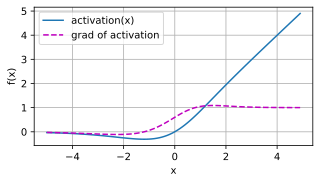

In [18]:
m = nn.Mish()
visualize_activation(x, m)

Swish（在 PyTorch 中也称为 SiLU）是由 Google Brain 团队在 2017 年利用自动搜索技术（Automated Search）发现的。它不仅是 Llama 2/3、Mistral 等顶级开源大模型的核心激活函数，也是 EfficientNet 等高效视觉网络的标配。它的出现标志着激活函数的设计从“人工推导”转向了“机器搜索+数学验证”的新阶段。  
1. 数学公式  
   Swish 是一个自门控（Self-Gated）激活函数，由输入 $x$ 乘以其 Sigmoid 值组成：  
   $$f(x) = x \cdot \sigma(\beta x) = \frac{x}{1 + e^{-\beta x}}$$
   在大多数实现（包括 Llama 和 PyTorch 的 nn.SiLU）中，参数 $\beta$ 默认设为 1。  
   当 $\beta \to \infty$ 时，它趋近于 ReLU；  
   当 $\beta \to 0$ 时，它趋近于线性函数 $f(x) = x/2$。
2. 核心精髓（特点）  
   非单调性（Non-monotonicity）：与 Mish 类似，Swish 在 $x$ 接近 0 的负区间有一个微小的“下凹陷”。这种特性允许网络保留一小部分负向特征，增加了梯度的复杂度和表现力。  
   平滑的门控机制：你可以把它理解为一个软门控：输入 $x$ 决定了有多少比例的信息可以通过。这种平滑性使得它在深层网络中比 ReLU 更好优化，损失函数表面更平滑。  
   Llama 架构的灵魂：在 Llama 的 SwiGLU 变体中，Swish 被集成到了门控线性单元里。这种组合被证明是目前大语言模型（LLM）实现高性能预测的关键因素之一。  
   计算效率：相比于 Mish，Swish 的数学表达式更简单（只需计算一次 Sigmoid），计算开销介于 ReLU 和 GELU 之间。
3. 适用场景  
   大语言模型 (LLM)：它是 Transformer 进阶版架构（如 Llama, PaLM）的默认选择。  
   轻量化高精度模型：EfficientNet 使用 Swish 达到了当时卷积神经网络的效率巅峰。  
   替代 ReLU/GELU：如果你追求比 ReLU 更高的精度，但又觉得 GELU 的高斯分布假设不符合你的数据特征，Swish 是一个极其稳健的中庸选择。

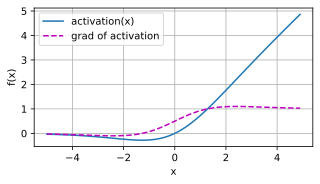

In [19]:
m = nn.SiLU()
visualize_activation(x, m)

GLU（门控线性单元）最早由 Dauphin 等人在 2016 年提出。严格来说，它不只是一个激活函数，而是一个具有门控机制的神经网络层。它的灵感来源于 LSTM 中的门控单元，目的是通过一个“开关”来决定哪些信息可以传递给下一层。它是目前大语言模型（LLM）中 GLU 变体架构（如 SwiGLU, GeGLU）的基础。
1. 数学公式  
   GLU 将输入向量平分为两部分：$a$ 和 $b$，然后用 $b$ 经过 Sigmoid 后的结果作为门控，去控制 $a$：  
   $$GLU(a, b) = a \otimes \sigma(b)$$
   其中：$a, b$ 通常是输入 $x$ 经过两个不同的线性变换（矩阵相乘）得到的。  
   $\otimes$ 是逐元素相乘（Element-wise product）。  
   $\sigma$ 是 Sigmoid 函数，充当“门控系数”（0 到 1 之间）。
2. 核心精髓（特点）  
   动态控制流：普通的激活函数（如 ReLU）是根据值的大小静态决定是否通过。而 GLU 是通过另一部分特征 $b$ 动态地决定 $a$ 的通过比例。这赋予了模型极强的选择性表达能力。  
   缓解梯度消失：由于 $\sigma(b)$ 提供了一个线性路径（即使 $a$ 的梯度较小，$b$ 的门控路径也能保持梯度流动），GLU 在训练极深的网络（如几百层的卷积或 Transformer）时比单纯的 ReLU 更稳定。  
   计算换精度：它的代价很明显——参数量翻倍。为了得到 $a$ 和 $b$，你需要两组权重矩阵。但在参数量即正义的大模型时代，这种权衡被证明是非常划算的。
   演进：SwiGLU (Llama 的核心)在大模型中，人们发现把 Sigmoid 换成 Swish (SiLU)，效果会更上一层楼，这就是 SwiGLU：  
   $$SwiGLU(x) = (W_1 x + b_1) \otimes \text{SiLU}(W_2 x + b_2)$$
   这是目前 Llama 2/3、Grok、Mistral 等模型在 FFN（前馈网络）层使用的秘密武器。
3. 适用场景  
   大语言模型 (LLM)：作为 Transformer 中 FFN 层的升级版。  
   语言建模与语音处理：最初在门控卷积网络（Gated CNN）中表现卓越。  
   需要精细特征控制的任务：当你希望模型能够学会“有选择地忽略噪声”时。

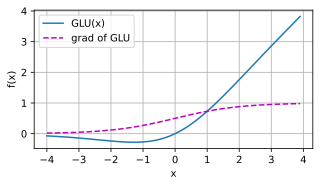

In [25]:
# dim=-1 表示在最后一个维度进行分割
m = nn.GLU(dim=-1)

# 2. 构造 2 列数据 (Leaf Tensor)
# 第一列是 a (内容)，第二列是 b (门控)
# 我们让 a 和 b 随 x 一起变化，这样能看到函数形状
x_base = torch.arange(-4.0, 4.0, 0.1)
x = torch.stack([x_base, x_base], dim=1).detach().requires_grad_(True) 

# 3. 运行前向传播
y = m(x) # 输出形状将从 [80, 2] 变为 [80, 1]

# 4. 修复 backward 形状冲突
if x.grad is not None: x.grad.zero_()
# 关键：这里用 y 维度对齐
y.backward(torch.ones_like(y), retain_graph=True)

# 5. 可视化 (取第一列的梯度来代表函数的变化趋势)
d2l.plot([x_base, x_base], 
         [y.detach().reshape(-1), x.grad[:, 0].reshape(-1)], 
         legend=['GLU(x)', 'grad of GLU'],
         xlabel='x', ylabel='f(x)', 
         figsize=(5, 2.5))

如果说目前大模型（LLM）领域有一个“版本答案”，那一定是 SwiGLU。它是 Llama 2/3、DeepSeek、Mistral 等几乎所有主流开源大模型在前馈网络（FFN）层中使用的核心激活机制。SwiGLU 是由 Google 的 Shazeer 在 2020 年的论文《GLU Variants Improve Transformer》中提出的。研究表明，它在语言建模任务上的表现几乎全面超越了传统的 ReLU 和 GELU。
1. 数学公式  
   SwiGLU 是 GLU 架构与 Swish (SiLU) 激活函数的完美结合。它通过两个线性变换的输出来进行“门控”：
   $$SwiGLU(x, W, V, b, c) = \text{Swish}_{\beta}(xW + b) \otimes (xV + c)$$
   在 LLM 的实际工程实现中，通常会简化掉偏置（Bias），并将 $\beta$ 设为 1，公式变为：  
   $$SwiGLU(x) = \text{SiLU}(xW) \otimes (xV)$$
   $W$ 和 $V$ 是两个独立的权重矩阵。  
   $\otimes$ 是逐元素相乘（Element-wise product）。  
   左侧路径 $\text{SiLU}(xW)$ 作为门控信号，决定了右侧路径 $(xV)$ 中哪些特征能够通过。
2. 核心精髓（特点）  
   极强的特征选择能力：普通的激活函数是“自己对自己”进行非线性变换。而 SwiGLU 是由路径 B 的线性特征去控制路径 A 的非线性特征。这种双路径交互模式让模型能够更精细地过滤信息。  
   训练稳定性与表达力：SiLU 函数本身的平滑性和非单调性（负区间的小凹陷）已经很优秀，结合了门控结构后，它在处理长文本序列时的梯度流动更加顺畅，不易出现神经元死掉的情况。  
   计算量的权衡：  
   缺点：相比于只用一个矩阵的 ReLU FFN，SwiGLU 需要三个矩阵（$W, V$ 以及输出投影矩阵 $W_2$），参数量和计算量增加了约 $1/2$。  
   优点：实验证明，这种参数量的增加换来的模型收益（Loss 下降）远超同等参数下的其他架构。  
3. 为什么 DeepSeek 和 Llama 都选它？  
   在大模型的 Transformer 层中，FFN 层占据了约 2/3 的计算量。早期的 GPT 使用 GELU，但后来的研究发现：  
   更宽的瓶颈层：SwiGLU 鼓励模型学习更复杂的特征组合。  
   更平滑的损失曲面：相比 ReLU，SwiGLU 产生的梯度更加稳定，这对于动辄数千亿参数的模型训练至关重要。  
   稀疏性潜力：在 DeepSeek 这种 MoE（混合专家模型）架构中，SwiGLU 的门控特性可以更好地与专家路由逻辑协同，提高计算效率。

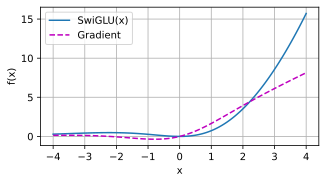

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from d2l import torch as d2l

# 1. 定义类
class SwiGLU(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.w_combined = nn.Linear(in_dim, out_dim * 2, bias=False)

    def forward(self, x):
        combined = self.w_combined(x)
        gate, res = torch.chunk(combined, 2, dim=-1)
        return F.silu(gate) * res

# 2. 准备模型 (1D -> 1D 方便画图)
m = SwiGLU(in_dim=1, out_dim=1)
with torch.no_grad():
    m.w_combined.weight.fill_(1.0) # 统一权重，看标准形状

# 3. 构造数据 (关键：直接创建 2D 叶子张量)
# 注意这里先 reshape 再 requires_grad_()
x = torch.linspace(-4.0, 4.0, 100).reshape(-1, 1).detach().requires_grad_(True)

# 4. 可视化函数
def visualize_swiglu(x, model):
    y = model(x)
    
    # 清除之前的梯度（如果有）
    if x.grad is not None: x.grad.zero_()
    
    # backward 的梯度形状必须对齐输出 y
    y.backward(torch.ones_like(y), retain_graph=True)
    
    # 检查梯度是否存在
    if x.grad is None:
        print("错误：梯度未生成！请确保 x 是叶子张量。")
        return

    # 绘图：转为 1D 数组给 d2l.plot
    d2l.plot([x.detach().reshape(-1), x.detach().reshape(-1)], 
             [y.detach().reshape(-1), x.grad.reshape(-1)], 
             legend=['SwiGLU(x)', 'Gradient'],
             xlabel='x', ylabel='f(x)', 
             figsize=(5, 2.5))

# 运行
visualize_swiglu(x, m)

GeGLU 是 Google 的 PaLM (Pathways Language Model) 及其后续变体（如早期版本的 Med-PaLM）所采用的标配激活函数。它是 GLU 家族中的另一位强力成员。如果说 SwiGLU 是 Llama 的灵魂，那么 GeGLU 就是 Google 系大模型的基石。
1. 数学公式  
   GeGLU 的结构与 SwiGLU 完全一致，唯一的区别在于将门控函数从 SiLU 换成了 GELU：  
   $$GeGLU(x, W, V) = \text{GELU}(xW) \otimes (xV)$$
   $xW$：门控分支，通过 GELU 激活后产生概率门控信号。  
   $xV$：线性特征分支。  
   $\otimes$：逐元素相乘。  
2. 核心精髓（特点）  
   统计学美感：由于 GELU 本身是基于高斯分布累积分布函数（CDF）定义的，GeGLU 在处理具有正态分布特性的隐含层特征时，逻辑上更加契合统计学规律。  
   更强硬的非线性：相比于 SwiGLU (SiLU)，GELU 在负区间的“凹陷”稍微深一点，且向正区间的过渡更贴近正态分布边缘。在某些特定的语言建模任务中，这种微小的形状差异能带来更好的拟合能力。  
   PaLM 的效率选择：Google 在训练 PaLM (540B 参数) 时发现，使用 GeGLU 配合其特有的“并行 Transformer 层”结构，能够显著提升模型在大规模 TPU 集群上的训练稳定性。  
   参数冗余的红利：和 SwiGLU 一样，GeGLU 将 FFN 的隐藏层维度扩大（通常是输入的 $2/3$ 或 $8/3$ 比例），利用更多的参数来换取更精细的特征门控。  
3. SwiGLU vs GeGLU：究竟谁更强？这是大模型圈子里长盛不衰的争论。  
   根据 Shazeer (2020) 的实验结论：性能差距极小：两者都显著优于传统的 ReLU 和单纯的 GELU。  
   细微差别：  
    GeGLU：在一些逻辑推理和纯文本建模上略显稳健。  
    SwiGLU：在当前主流的 Llama 类架构中表现出了更好的通用性，尤其是配合特定的权重初始化时。  
   计算成本：两者基本持平。虽然 GELU 的精确计算比 SiLU 复杂，但通过 tanh 近似后，在硬件层面的延迟几乎没有区别。

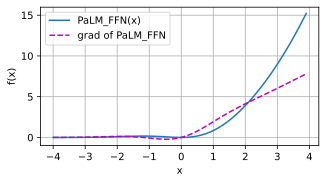

In [22]:
# 同样，PyTorch 并没有内置 nn.GeGLU，但我们可以快速实现它。通常我们会把 FFN 的第一个线性层做成两倍输出宽度：
class GeGLU(nn.Module):
    def forward(self, x):
        # 假设输入 x 的最后一个维度已经经过了 Linear(in, out*2)
        # 将输入切分为门控部分 a 和线性部分 b
        a, b = x.chunk(2, dim=-1)
        return F.gelu(a) * b

# 完整 FFN 结构示意
class PaLM_FFN(nn.Module):
    def __init__(self, dim, intermediate_dim):
        super().__init__()
        # 升维：从 d 变到 2 * intermediate_dim
        self.wi = nn.Linear(dim, intermediate_dim * 2, bias=False)
        self.wo = nn.Linear(intermediate_dim, dim, bias=False)
        self.geglu = GeGLU()

    def forward(self, x):
        return self.wo(self.geglu(self.wi(x)))

# 2. 模拟单输入单输出场景
dim, intermediate_dim = 1, 1
model = PaLM_FFN(dim, intermediate_dim)

# 固定权重为 1，确保可视化结果具有通用性（不被随机初始化干扰）
with torch.no_grad():
    model.wi.weight.fill_(1.0)
    model.wo.weight.fill_(1.0)

# 3. 构造数据
# 1. 先创建 2D 形状的原始张量，使其成为叶子节点
x = torch.arange(-4.0, 4.0, 0.1).reshape(-1, 1)
# 2. 显式开启梯度
x.requires_grad_(True) 

# 现在 x 是一个叶子张量，backward 之后 x.grad 就会有值了
y = model(x)

# 4. 计算梯度 (dy/dx)
if x.grad is not None: x.grad.zero_()
y.backward(torch.ones_like(y), retain_graph=True)

# 5. 使用 d2l.plot 可视化
# 注意：d2l.plot 要求传入的列表元素需要是 1D 数组，所以用 detach().reshape(-1)
d2l.plot([x.detach().reshape(-1), x.detach().reshape(-1)], 
         [y.detach().reshape(-1), x.grad.reshape(-1)], 
         legend=['PaLM_FFN(x)', 'grad of PaLM_FFN'], 
         xlabel='x', ylabel='f(x)', 
         figsize=(5, 2.5))

ReGLU (ReLU-Gated Linear Unit)ReGLU 是 GLU（门控线性单元）家族中最基础、最高效的变体。它将经典的 ReLU 激活函数引入门控机制，旨在通过简单的逻辑实现复杂的特征过滤。
1. 数学公式  
   ReGLU 将输入向量投影到两个不同的线性空间，其中一个路径经过 ReLU 激活作为“门”，去控制另一个路径的信息流：  
   $$ReGLU(x, W, V, b, c) = \text{ReLU}(xW + b) \otimes (xV + c)$$
   在当前大模型的实际工程（如 Transformer 的 FFN 层）中，为了极致的计算效率，通常省略偏置项：  
   $$ReGLU(x) = \max(0, xW) \otimes (xV)$$
   $xW$：门控分支，决定哪些特征被留下（正值通过，负值置零）。  
   $xV$：特征分支，携带待处理的原始信息。  
   $\otimes$：逐元素相乘。
2. 核心精髓  
   硬稀疏性（Hard Sparsity）：由于 ReLU 在 $x \le 0$ 时输出绝对为 $0$，ReGLU 拥有真正的“零输出”能力。这种硬截断特性可以显著抑制噪声，并让模型学习到更具稀疏性和可解释性的特征表达。  
   二阶交互潜力：与传统的 ReLU 层相比，ReGLU 通过两个变量的乘积（$W$ 路径与 $V$ 路径）引入了非线性。在 $x > 0$ 时，它表现出类似于 $x^2$ 的二阶特性，这赋予了模型捕捉更高阶特征组合的能力。  
   计算零开销：相比于需要计算指数或双曲正切的 SwiGLU 或 GeGLU，ReGLU 仅需一次位运算级别的比较（max）。在硬件层面，它是 GLU 家族中指令周期最短、计算速度最快的成员。
3. 适用场景  
   实时推理与低延迟系统：在对响应速度要求极高的场景（如高频交易、实时自动驾驶决策、在线搜索推荐）中，ReGLU 能够减少激活函数的计算延迟。  
   端侧 AI 与嵌入式设备：在算力有限的手机、单片机或边缘 NPU 上，ReGLU 不需要复杂的超越函数查找表（Lookup Table），是性能与功耗平衡的最佳选择。  
   大规模特征筛选任务：在处理具有极其稀疏特征的数据（如点击率预测 CTR、推荐算法中的 Embedding 过滤）时，ReGLU 的硬门控特性能够更自然地适配数据的稀疏性质。  
   轻量化模型架构：当你尝试压缩模型（如剪枝或量化）时，ReGLU 产生的零值更多，更有利于稀疏矩阵加速和权重压缩。

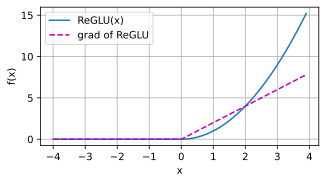

In [26]:
# 1. 你的 ReGLU 定义
class ReGLU(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features * 2, bias=False)

    def forward(self, x):
        a, b = self.linear(x).chunk(2, dim=-1)
        return F.relu(a) * b

# 2. 初始化模型 (1D -> 1D 方便画图)
model = ReGLU(in_features=1, out_features=1)

# 手动固定权重为 1.0，以便观察最标准的 ReGLU 形状
with torch.no_grad():
    model.linear.weight.fill_(1.0)

# 3. 构造数据 (关键：直接创建 2D 叶子张量)
# 我们需要输入是 (Batch, 1)，绘图需要的是 1D 数组
x_axis = torch.arange(-4.0, 4.0, 0.1)
x = x_axis.reshape(-1, 1).detach().requires_grad_(True)

# 4. 前向传播
y = model(x)

# 5. 反向传播计算梯度 (dy/dx)
if x.grad is not None: x.grad.zero_()
y.backward(torch.ones_like(y), retain_graph=True)

# 6. 使用 d2l.plot 可视化
# 注意：要把 y 和 x.grad 都 reshape(-1) 转回 1D 数组
d2l.plot([x_axis, x_axis], 
         [y.detach().reshape(-1), x.grad.reshape(-1)], 
         legend=['ReGLU(x)', 'grad of ReGLU'], 
         xlabel='x', ylabel='f(x)', 
         figsize=(5, 2.5))

Hard-Swish 是由 Google 在 MobileNetV3 论文中提出的一种激活函数。它是对标准 Swish（即 SiLU）的低成本近似，专门为在算力受限的移动端设备上高效运行而设计。  
1. 数学公式  
   标准的 Swish 函数定义为 $x \cdot \text{sigmoid}(x)$。由于 Sigmoid 涉及指数运算（$\frac{1}{1+e^{-x}}$），在移动端硬件上计算成本较高。  
   Hard-Swish 用一个分段线性函数（ReLU6 的变体）来代替 Sigmoid：  
   $$\text{h-swish}(x) = x \frac{\text{ReLU6}(x + 3)}{6}$$
   其中 $\text{ReLU6}(x) = \min(\max(0, x), 6)$。  
   展开来看，它的分段定义为：  
   如果 $x \le -3$，$y = 0$  
   如果 $x \ge +3$，$y = x$  
   如果 $-3 < x < 3$，$y = \frac{x(x + 3)}{6}$
2. 核心精髓  
   计算友好（Hardware Efficient）：它完全避免了指数运算。在移动端架构中，加法、乘法和线性截断（ReLU6）的指令周期极短。将 $\text{sigmoid}$ 替换为 $\text{ReLU6}(x+3)/6$ 可以显著减少推理时间。  
   平滑性近似：虽然它是分段线性的，但它保留了标准 Swish 的关键非单调性（在负值区域有一个微小的下潜）。这使得它在保持模型精度的同时，比原始 ReLU 拥有更好的信息流动性。  
   减少量化损失：由于 Hard-Swish 主要是线性的组合，它在进行 8-bit 量化（Quantization）时表现得比带有复杂曲线的 Sigmoid 更稳定，不容易产生严重的精度波动。
3. 适用场景  
   轻量化神经网络：它是 MobileNetV3、EfficientNet-Lite 以及各种针对手机端优化的目标检测模型（如 YOLOv5/v8-tiny 变体）的标配。  
   移动端推理加速：当你需要将模型部署到端侧 NPU、DSP 或低算力 ARM 核心上时，Hard-Swish 是首选。  
   实时计算机视觉：在需要每秒处理数百帧图像的嵌入式视觉任务中，Hard-Swish 能在几乎不损失精度的情况下榨取性能。

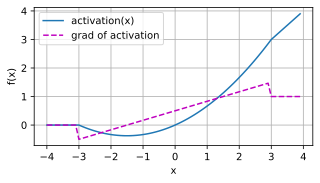

In [ ]:
# 1. 官方在 torch.nn 中内置了 Hardswish
m = nn.Hardswish()

# 2. 准备数据 (Leaf Tensor)
x = torch.arange(-4.0, 4.0, 0.1, requires_grad=True)

visualize_activation(x,m)

Maxout 是一种特殊的激活函数，由 Ian Goodfellow（GAN 之父）在 2013 年提出。它与 ReLU 或 Sigmoid 等固定数学形式的激活函数不同，Maxout 本质上是一个学习型的激活函数。  
1. 数学公式  
   Maxout 层可以看作是隐藏层的一个改进。给定输入 $x \in \mathbb{R}^d$，Maxout 并不是对每个神经元直接进行非线性映射，而是计算 $k$ 个线性函数的最大值：  
   $$y = \max(z_1, z_2, \dots, z_k)$$
   其中每个 $z_i$ 都是一个独立的线性变换：$$z_i = xW_i + b_i$$通常 $k$ 取 2。这意味着对于每一个输出神经元，Maxout 都会维护 $k$ 组不同的权重和偏置。  
2. 核心精髓  
   拟合任何凸函数 (Universal Approximator)：由于 Maxout 是多个线性函数的逐点最大值（Piecewise Linear），它可以模拟任何连续的凸函数。例如，当 $k=2$ 且设置特定的权重时，Maxout 可以完美实现 ReLU、$|x|$（绝对值激活）或者 Leaky ReLU。  
   解决神经元坏死 (No Dying Neurons)：ReLU 在 $x < 0$ 时梯度为 0，可能导致神经元“坏死”。但 Maxout 的每个部分都是线性的，且总有一个分支会被选中。只要至少有一个分支有梯度，神经元就能持续更新。  
   与 Dropout 完美配合：Maxout 最初是为了配合 Dropout 提出的。Dropout 相当于在训练时随机丢弃神经元，而 Maxout 的这种多线性组合结构在模型平均（Model Averaging）时表现得非常稳健，能够提升泛化能力。  
   参数量翻倍：这是 Maxout 的主要缺点。为了实现一个输出神经元，你需要存储 $k$ 组权重。如果 $k=2$，参数量直接比普通神经网络增加了一倍。  
3. 适用场景  
   对抗神经网络 (GANs)：在 GAN 的判别器或生成器中，Maxout 的灵活性有助于学习复杂的数据分布。  
   需要强拟合能力的深层网络：当你发现 ReLU 导致严重的神经元失效（Dying ReLU）且无法通过调小学习率解决时，Maxout 是一个强力的替代方案。  
   特定的小型高精模型：如果模型规模受限（层数不多），但你希望每一层都能表达更复杂的非线性，Maxout 可以通过增加单层参数量来换取更强的表达力。

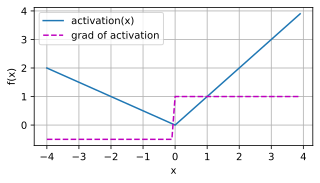

In [28]:
# 1. 实现一个简单的 Maxout (k=2)
class Maxout(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # 模拟两个分支 z1 和 z2
        # 在实际模型中，这两个 z 是由 nn.Linear(in, out*k) 生成并拆分的
        z1 = x
        z2 = -0.5 * x
        return torch.max(z1, z2)
m=Maxout()

visualize_activation(x,m)

LogSoftmax 是深度学习中极其重要的一个函数，尤其在处理多分类任务时。虽然从数学上看它只是 $\log(\text{Softmax}(x))$，但在工程实现上，直接先算 Softmax 再取 Log 会导致严重的数值不稳定。  
1. 数学公式  
   对于一个向量 $x$ 中的第 $i$ 个元素，其 LogSoftmax 定义为：  
   $$\text{LogSoftmax}(x_i) = \log\left( \frac{\exp(x_i)}{\sum_{j} \exp(x_j)} \right)$$
   展开后利用对数性质可以得到：  
   $$\text{LogSoftmax}(x_i) = x_i - \log\left( \sum_{j} \exp(x_j) \right)$$
   这种展开形式被称为 Log-Sum-Exp (LSE)，它是计算 LogSoftmax 的标准方式，能够有效防止数值溢出（Overflow）。
2. 核心精髓  
   解决数值溢出（Numerical Stability）：Softmax 中的 $\exp(x)$ 在 $x$ 很大时会变成 inf，而 $\exp(x)$ 在 $x$ 很小时会变成 0。LogSoftmax 通过 LSE 技巧（减去最大值）避免了直接计算极大的指数幂，保证了计算的稳定性。  
   配合 NLLLoss（负对数似然损失）：在 PyTorch 中，nn.CrossEntropyLoss 实际上就是 nn.LogSoftmax + nn.NLLLoss。直接在输出层使用 LogSoftmax 可以让后续的梯度计算变得极其简单且线性，避免了在概率极小时梯度消失的问题。  
   改善优化曲面：LogSoftmax 将原始的概率区间 $(0, 1]$ 映射到了 $(-\infty, 0]$。在对数空间中进行操作，可以将概率的乘法运算转换为加法运算，这使得优化器的搜索空间更加开阔，收敛更平稳。
3. 适用场景  
   多分类任务的输出层：当你使用 nn.NLLLoss 时，输出层必须经过 nn.LogSoftmax。  
   强化学习（RL）中的策略分布：在计算 Actor 的策略梯度时，通常需要计算动作概率的对数（$\log \pi(a|s)$），直接使用 LogSoftmax 既快又稳。  
   大规模词表分类：在语言模型（如 BERT, GPT）的预测头中，面对成千上万个词的分类，LogSoftmax 是确保损失函数计算不崩溃的关键。

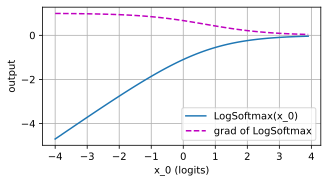

In [29]:
# 1. 定义 LogSoftmax
m = nn.LogSoftmax(dim=0)

# 2. 准备数据
# 模拟一个三分类的 logits，固定另外两个，观察第一个的变化
def logsoftmax_plot(x_val):
    # 构建向量 [x, 0, 0]
    # dim=0 会在这三个数之间进行 logsoftmax
    logits = torch.stack([x_val, torch.zeros_like(x_val), torch.zeros_like(x_val)], dim=0)
    return m(logits)[0] # 只取第一个分量的结果

x = torch.arange(-4.0, 4.0, 0.1, requires_grad=True)
y = logsoftmax_plot(x)

# 3. 计算梯度
if x.grad is not None: x.grad.zero_()
y.backward(torch.ones_like(x), retain_graph=True)

# 4. 可视化
d2l.plot([x.detach(), x.detach()], 
         [y.detach(), x.grad], 
         legend=['LogSoftmax(x_0)', 'grad of LogSoftmax'], 
         xlabel='x_0 (logits)', ylabel='output', 
         figsize=(5, 2.5))

Sparsemax 是由 Martins 和 Astudillo 在 2016 年提出的一种激活函数。它是 Softmax 的一种竞争性替代方案。Softmax 的输出是一个严格正数的概率分布（即使概率再小，也会有一个极小的正值，如 $10^{-10}$），而 Sparsemax 能够输出真正的 0，从而产生稀疏的概率分布。  
1. 数学公式  
   Sparsemax 的本质是寻找一个最接近输入向量 $z$ 的欧几里得投影，使其落入一个概率单纯形（Probability Simplex）中：  
   $$\text{sparsemax}(z) = \text{argmin}_{p \in \Delta^{K-1}} \| p - z \|^2$$
   通俗地说，它在数学实现上表现为一个“阈值截断”操作：  
   $$\text{sparsemax}(z_i) = \max(0, z_i - \tau(z))$$
   其中 $\tau(z)$ 是一个根据向量 $z$ 自动计算出的阈值。如果某个分量 $z_i$ 足够小（小于阈值 $\tau$），它的输出就会被强制设为 0。
2. 核心精髓  
   真正的稀疏性 (Exact Sparsity)：Softmax 倾向于给所有类别分配一点概率（哪怕是无关的干扰项），而 Sparsemax 可以完全忽略掉那些低置信度的类别。这使得模型更加专注。  
   可解释性 (Interpretability)：在注意力机制（Attention）中使用 Sparsemax，模型会明确指出它“只看了这三个词”，而对其余词的权重完全为 0。这种“有选择的关注”比 Softmax 的“模糊关注”更容易被人类理解。  
   计算开销略高：由于需要计算阈值 $\tau$（通常涉及对输入向量进行排序），其计算复杂度为 $O(K \log K)$，略高于 Softmax 的 $O(K)$。  
   保持分段线性：与 Softmax 的指数曲线不同，Sparsemax 是分段线性的。这使得它的梯度在非零区域更加稳定，不容易出现 Softmax 那样的梯度消失问题。
3. 适用场景  
   稀疏注意力机制 (Sparse Attention)：在长文本处理中，为了让模型专注于最相关的部分并减少计算干扰。  
   多标签分类：当一个样本属于成千上万个类别中的某几个时，Sparsemax 可以直接过滤掉绝大多数不相关的标签。  
   需要可解释性的任务：如医疗诊断、法律文书分析，需要明确指出决策依据的权重分布。

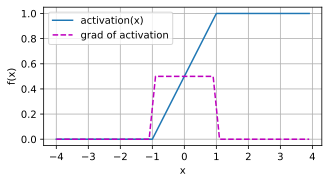

In [30]:
# 1. 简单的 Sparsemax 二维实现 (针对向量 [x, 0])
def sparsemax_2d(x_val):
    # 对于二维向量 [z1, z2]，sparsemax 的阈值 tau = (z1 + z2 - 1) / 2 (如果都在范围内)
    # 这里我们简化逻辑以展示其截断特性
    # 当 |z1 - z2| > 1 时，就会出现 0 或 1
    z1 = x_val
    z2 = torch.zeros_like(x_val)
    
    # 投影到单纯形的简化计算
    output = torch.max(torch.zeros_like(z1), (z1 - z2 + 1) / 2)
    output = torch.min(torch.ones_like(output), output)
    return output

m=sparsemax_2d
visualize_activation(x,m)

Softsign 是一种早在 2010 年左右就被提出的激活函数，它与 Tanh（双曲正切）非常相似，都是对称的 S 型（Sigmoid-like） 函数。但在数学实现上，它用多项式结构代替了 Tanh 的指数结构，这使得它在某些方面表现得更加“温和”。
1. 数学公式  
   Softsign 的定义非常简洁，只涉及基本的加法、除法和绝对值运算：  
   $$f(x) = \frac{x}{1 + |x|}$$
   其输出范围被严格限制在 $(-1, 1)$ 之间：  
   当 $x \to \infty$ 时，$y \to 1$  
   当 $x \to -\infty$ 时，$y \to -1$  
   当 $x = 0$ 时，$y = 0$  
2. 核心精髓  
   平滑的饱和（Gentle Saturation）：这是 Softsign 最核心的特性。相比于 Tanh 的指数级饱和（Tanh 在 $|x| > 3$ 时几乎就变成了平平的一条线），Softsign 的饱和过程是多项式级的。  
   Tanh：导数消失得极快。Softsign：导数下降得更慢，能更久地保持梯度。这在深层网络中可以缓解一定程度的梯度消失问题。  
   计算开销极低：它不涉及 $e^x$ 这种复杂的超越函数运算。在早期的硬件环境下，计算绝对值和除法比计算指数快得多。  
   零点对称（Zero-Centered）：输出以 0 为中心，这有助于保持每一层输出的均值为 0，从而使下一层的权重更新更加稳定（类似于 Batch Normalization 的部分作用）。  
3. 适用场景  
   早期的循环神经网络（RNN）：在计算资源有限且需要 Tanh 特性的场景中，Softsign 是一个很好的轻量级替代品。  
   回归任务的输出层：当目标值位于 $(-1, 1)$ 且你希望模型在远离中心点时不要过快地丧失学习动力（梯度）时，Softsign 比 Tanh 更好。  
   语音处理与信号处理：在需要压缩信号动态范围，但又不希望像硬截断（Clamping）那样产生过多高频噪声时。

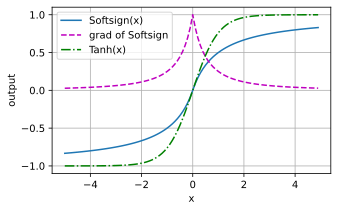

In [31]:
# 1. 定义 Softsign 和 Tanh 用于对比
softsign = nn.Softsign()
tanh = nn.Tanh()

# 2. 准备数据
x = torch.arange(-5.0, 5.0, 0.1, requires_grad=True)
y_soft = softsign(x)
y_tanh = tanh(x)

# 3. 计算 Softsign 梯度
if x.grad is not None: x.grad.zero_()
y_soft.backward(torch.ones_like(x), retain_graph=True)
grad_soft = x.grad.clone()

# 4. 可视化
# 我们画出 Softsign 函数及其梯度，顺便带上 Tanh 做对比
d2l.plot(x.detach(), 
         [y_soft.detach(), grad_soft, y_tanh.detach()], 
         legend=['Softsign(x)', 'grad of Softsign', 'Tanh(x)'], 
         xlabel='x', ylabel='output', 
         figsize=(5, 3))

Bent-Identity 是一种对标准线性函数（Identity）进行微小修饰的激活函数。它在 2010 年代初左右被提出，旨在通过引入某种“弯曲”来打破线性，同时又保留线性函数在正负区间都能无限延伸的特性。
1. 数学公式  
   Bent-Identity 的公式结合了线性和非线性项：  
   $$f(x) = \frac{\sqrt{x^2 + 1} - 1}{2} + x$$
   它的导数（梯度）为：  
   $$f'(x) = \frac{x}{2\sqrt{x^2 + 1}} + 1$$
   当 $x$ 很大时，函数趋近于 $x + 0.5$。  
   当 $x$ 很小时，函数趋近于 $x - 0.5$。  
   在 $x=0$ 附近，它表现出平滑的非线性。  
2. 核心精髓  
   打破线性（Breaking Linearity）：标准的 Identity 函数（$y=x$）是纯线性的，无法学习复杂的特征。Bent-Identity 通过那部分根号项给函数加了一个“弯曲”，使其具备了非线性表达能力。  
   无饱和性（No Saturation）：与 Sigmoid、Tanh 或 Softsign 不同，Bent-Identity 在正负两个方向上都没有上限或下限。这意味着它在任何数值范围内都不会出现梯度消失的情况。  
   平滑性：与 ReLU 在 $x=0$ 处的突变不同，Bent-Identity 在全定义域内都是二阶可导的，这使得基于二阶导数的优化算法（如海森矩阵方法）表现得更加稳定。  
   接近线性：它的核心依然是“Identity”。对于那些大部分特征接近线性、只需少量非线性修正的任务，它比激进的 ReLU 或 Swish 更稳健。  
3. 适用场景  
   深度残差网络（Residual Networks）的变体：在某些需要极深层数且希望特征尽量保持原始比例（Identity Shortcut）的研究中，可以使用 Bent-Identity 作为激活函数。  
   回归分析（Regression）：在预测连续值的任务中，如果目标值跨度极大且分布不均，可以使用它来提供平滑的非线性过渡，同时保证梯度在远端不消失。  
   替代线性层：在某些网络层中，如果你不确定是否需要强非线性，可以使用 Bent-Identity 作为一个“带有一点点非线性”的备选方案。

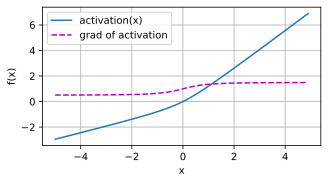

In [32]:
# 1. 定义 Bent-Identity 函数
def bent_identity(x):
    return (torch.sqrt(x**2 + 1) - 1) / 2 + x

visualize_activation(x, bent_identity)

Sinc 函数在信号处理（Signal Processing）领域是家喻户晓的“明星”，但在神经网络激活函数中，它则属于比较硬核、小众的选择。它由采样定理的奠基人引入，能够完美地在离散采样和连续信号之间进行转换。
1. 数学公式  
   在神经网络中使用的通常是非归一化 Sinc 函数：
   $$f(x) = \text{sinc}(x) = \begin{cases} \frac{\sin(x)}{x} & x \neq 0 \\ 1 & x = 0 \end{cases}$$
   其导数（梯度）为：  
   $$f'(x) = \frac{\cos(x)}{x} - \frac{\sin(x)}{x^2}$$
2. 核心精髓  
   局部周期性与波动性：与绝大多数单调递增的激活函数（如 ReLU, Sigmoid）不同，Sinc 是非单调的，且在远离原点时具有衰减的振荡特性。这使得它能够捕捉数据中的周期性模式或频率特征。  
   频域特性（低通滤波）：在数学上，Sinc 函数的傅里叶变换是一个矩形窗（Rectangular Window）。这意味着在网络层中使用 Sinc 激活，本质上是在进行某种形式的频域限制或滤波，有助于模型学习平滑的特征表示。  
   无限可导性：它是解析函数，在全定义域内极其平滑，这对于需要高阶导数的物理信息神经网络（PINNs）非常友好。  
   中心对称与衰减：它以 $x=0$ 为中心（输出为 1），随着 $|x|$ 增大，输出迅速向 0 衰减。这种特性类似于某种“局部响应”机制。
3. 适用场景  
   物理信息神经网络 (PINNs)：用于求解波动方程、流体力学等具有周期性或振动特性的物理问题。  
   语音与音频处理：处理原始波形数据时，Sinc 函数的频域特性可以帮助模型更好地理解谐波和共振。  
   时间序列预测：对于具有明显季节性或周期性波动的金融、气象数据，Sinc 可以提供更自然的拟合基元。  
   专门的通信模型：在模拟无线信号传输、信道均衡等底层通信算法的神经网络中。

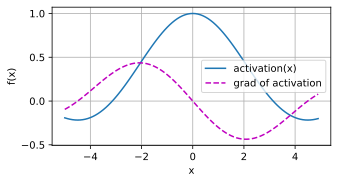

In [33]:
# 1. 定义 Sinc 函数 (需要处理 x=0 的特殊情况以防除以零)
def sinc_activation(x):
    # 使用 torch.where 处理 0 点，或者利用 sinc 的极限值
    # PyTorch 自带 torch.sinc，但它通常定义为 sin(pi*x)/(pi*x)
    # 我们这里手动实现神经网络中常用的非归一化版本
    res = torch.sin(x) / x
    res[x == 0] = 1.0
    return res
visualize_activation(x, sinc_activation)

Gaussian (高斯激活函数)Gaussian 激活函数在神经网络中属于一种径向基（Radial Basis）风格的选择。它不遵循常见的“阶梯状”或“线性延伸”设计，而是呈现为一个经典的“钟形曲线”。
1. 数学公式  
   高斯激活函数通常取标准正态分布的形式（不含归一化系数）：  
   $$f(x) = \exp(-x^2)$$
   其导数（梯度）为：  
   $$f'(x) = -2x \cdot \exp(-x^2) = -2x \cdot f(x)$$
   当 $x = 0$ 时，输出达到最大值 $1$。当 $|x|$ 增大时，输出迅速向 $0$ 衰减。它是典型的非单调且局部响应的函数。
2. 核心精髓  
   局部性（Locality）：这是高斯函数最显著的特点。它只对原点附近的输入产生强烈反应。在网络中，这意味着一个神经元只会被特定的输入范围“激活”，而在远离该范围时完全保持沉默。这类似于生物神经元的“感受野”概念。  
   无限可导与平滑性：高斯函数在整个实数域内无限可导，且图像极度平稳。这使得它在需要高精度数值特性的任务（如求解偏微分方程）中表现优异。  
   特征映射潜力：在数学上，高斯核是支持向量机（SVM）中常用的核函数，能够将低维数据映射到无限维的特征空间。作为激活函数，它赋予了单层神经网络极强的非线性拟合能力。  
   完全对称：它是一个偶函数 $f(x) = f(-x)$，这意味着它对输入的正负号不敏感，只关心输入的大小（模）。
3. 适用场景  
   径向基函数网络 (RBF Networks)：高斯函数是 RBF 网络的核心。这类网络在函数逼近、时间序列预测和系统控制中非常经典。  
   物理信息神经网络 (PINNs)：由于其优良的解析性质，常用于模拟平滑的物理场（如温度场、压力分布）。  
   局部特征提取：在某些需要识别特定数值模式的任务（如异常检测，判断某个指标是否偏移了正常中心）中效果很好。  
   生成模型：在变分自编码器（VAE）或某些扩散模型的中间层中，有时利用高斯函数的性质来处理潜在空间的分布。

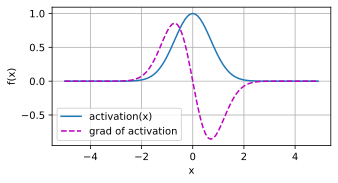

In [34]:
# 1. 定义 Gaussian 函数
def gaussian_activation(x):
    return torch.exp(-(x**2))
visualize_activation(x, gaussian_activation)

SQNL (Square Nonlinearity)SQNL 是在 2017 年左右提出的一种激活函数，旨在作为 Sigmoid 和 Tanh 的极简替代方案。它的设计初衷非常明确：彻底消灭指数运算 ($e^x$)，改用纯粹的多项式（平方项）来模拟 S 型曲线，从而大幅提升计算效率。
1. 数学公式  
   SQNL 是一个分段函数，它通过抛物线平滑地连接了 $[-2, 2]$ 之间的区域，并在两侧直接截断为常数：  
   $$f(x) = \begin{cases} 1 & x > 2.0 \\ x - \frac{x^2}{4} & 0 \le x \le 2.0 \\ x + \frac{x^2}{4} & -2.0 \le x < 0 \\ -1 & x < -2.0 \end{cases}$$
   其导数（梯度）在 $[-2, 2]$ 之间是线性的，在两侧为 0：  
   当 $0 \le x \le 2.0$ 时，$f'(x) = 1 - \frac{x}{2}$  
   当 $-2.0 \le x < 0$ 时，$f'(x) = 1 + \frac{x}{2}$   
2. 核心精髓  
   硬件极其友好 (FPGA/ASIC Optimized)：它只需要加法、减法、乘法和逻辑判断。对于不支持浮点指数运算的低端微控制器、FPGA 或自定义 AI 芯片来说，SQNL 可以在极少的时钟周期内完成计算。  
   计算开销比 Sigmoid/Tanh 低一个数量级：由于不需要复杂的级数展开或查找表（Lookup Table）来计算 $e^x$，它在 CPU 和移动端设备上的推理速度极快。  
   平滑的饱和性：虽然是分段函数，但它在 $x=0$ 处是一阶连续的，且在 $x= \pm 2$ 处平滑地进入饱和区。它保留了 Tanh 的基本形状，但曲线更加“平扁”。  
   零中心对称：输出范围在 $[-1, 1]$ 之间，有助于保持层与层之间的激活值均值接近 0。  
3. 适用场景   
   极低功耗嵌入式设备：如智能穿戴设备、传感器节点上的轻量级神经网络。  
   FPGA 神经网络加速器：在逻辑资源（LUTs）紧张的 FPGA 芯片上，SQNL 是实现非线性的高效方案。  
   实时推理需求极高的系统：在那些每一比特功耗和每一微秒延迟都要精打细算的工程任务中。

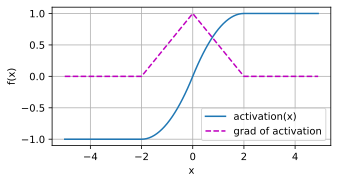

In [35]:
# 1. 实现 SQNL 函数
def sqnl_activation(x):
    # 分段处理
    y = torch.zeros_like(x)
    
    mask1 = x > 2.0
    y[mask1] = 1.0
    
    mask2 = (x >= 0) & (x <= 2.0)
    y[mask2] = x[mask2] - (x[mask2]**2) / 4.0
    
    mask3 = (x < 0) & (x >= -2.0)
    y[mask3] = x[mask3] + (x[mask3]**2) / 4.0
    
    mask4 = x < -2.0
    y[mask4] = -1.0
    
    return y
visualize_activation(x, sqnl_activation)